<a href="https://colab.research.google.com/github/Riyaz127/TNS-Practice/blob/main/Batch2_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded=files.upload()

Saving electric_vehicles_dataset.csv to electric_vehicles_dataset.csv


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as pt

In [21]:
df=pd.read_csv("electric_vehicles_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Vehicle_ID        50 non-null     object 
 1   Manufacturer      50 non-null     object 
 2   Model             50 non-null     object 
 3   Vehicle_Type      50 non-null     object 
 4   Battery_Capacity  50 non-null     int64  
 5   Range             50 non-null     int64  
 6   Efficiency        50 non-null     float64
 7   Charging_Time     50 non-null     float64
 8   Top_Speed         50 non-null     int64  
 9   Motor_Power       50 non-null     int64  
 10  Price             50 non-null     int64  
 11  Launch_Year       50 non-null     int64  
 12  Safety_Rating     50 non-null     float64
dtypes: float64(3), int64(6), object(4)
memory usage: 5.2+ KB


In [8]:
#Write a function to calculate the  energy efficiency of a vehicle?
def effi():
  df['Efficiency2']=df['Range']/df['Battery_Capacity']
effi()
df[['Vehicle_Type','Model','Range','Battery_Capacity','Efficiency2','Efficiency']]

,Vehicle_Type,Model,Range,Battery_Capacity,Efficiency2,Efficiency
0,SUV,Volt X 1,294,60,4.900000,4.9
1,Hatchback,Eon EV 7,270,50,5.400000,5.4
2,Hatchback,EcoRide 7,420,50,8.400000,8.4
3,SUV,Falcon 1,252,30,8.400000,8.4
4,Hatchback,Urban E 3,335,50,6.700000,6.7
5,Hatchback,Neo 6,184,40,4.600000,4.6
6,Hatchback,Eon EV 6,491,60,8.183333,8.2
7,Hatchback,Urban E 5,189,30,6.300000,6.3
8,Sedan,Eon EV 2,174,30,5.800000,5.8
9,SUV,Drive Pro 1,295,50,5.900000,5.9


Python Basic Questions:

In [30]:
#Write a function to classify vehicles:
"""Efficiency             Category
    >8                     Excellent
    6-8                    Good
    4-6                    Average
    <4                     Poor
"""
def classify(score):
  if score > 8:
    return 'Excellent'
  elif score >= 6 and score <= 8:
    return 'Good'
  elif score >= 4 and score < 6:
    return 'Average'
  else:
    return 'Poor'
df['Category']=df['Efficiency'].apply(classify)
df[['Vehicle_Type','Model','Range','Battery_Capacity','Efficiency','Category']].head(6)

,Vehicle_Type,Model,Range,Battery_Capacity,Efficiency,Category
0,SUV,Volt X 1,294,60,4.9,Average
1,Hatchback,Eon EV 7,270,50,5.4,Average
2,Hatchback,EcoRide 7,420,50,8.4,Excellent
3,SUV,Falcon 1,252,30,8.4,Excellent
4,Hatchback,Urban E 3,335,50,6.7,Good
5,Hatchback,Neo 6,184,40,4.6,Average


In [20]:
#Find all Vehicles whose: Range>400km ,Charging time <2, Safety rating>=4
df[(df['Range']>400) & (df['Charging_Time']<2) & (df['Safety_Rating']>=4)]

,Vehicle_ID,Manufacturer,Model,Vehicle_Type,Battery_Capacity,Range,Efficiency,Charging_Time,Top_Speed,Motor_Power,Price,Launch_Year,Safety_Rating,Efficiency2,Category
27,EV1028,Tata,Drive Pro 3,Sedan,75,532,7.1,1.1,253,83,5447214,2025,4.3,7.093333,Good


Questions on Numpy:

In [76]:
""" 1. Calculate: """
#mean Battery capacity
print('Mean of Battery capacity:',np.mean(df['Battery_Capacity']))
#mean vehicle range
print('Mean of Vehicle Range:',np.mean(df['Range']))
#standard deviation of prices
print('Standard Deviation of Prices:',np.std(df['Price']))
#maximum motor power
print('Maximum Motor Power:',np.max(df['Motor_Power']))
#minimum charging time
print('Minimum Charging Time:',np.min(df['Charging_Time']))


Mean of Battery capacity: 58.6
Mean of Vehicle Range: 380.2
Standard Deviation of Prices: 2055455.1715914886
Maximum Motor Power: 343
Minimum Charging Time: 0.8


In [39]:
"""2. Find the correlation coefficient between"""
#Battery Capacity and Range
Battery=df['Battery_Capacity'].corr(df['Range'])
print("Correlation of Battery Capicity and Range:",Battery)
#Price and Motor power
Price=df['Price'].corr(df['Motor_Power'])
print("Correlation of Price and Motor Power:",Price)
#Charging Time and Battery Capacity
charge=df['Charging_Time'].corr(df['Battery_Capacity'])
print("Correlation of Charging Time and Battery Capacity:",charge)
df.info()

Correlation of Battery Capicity and Range: 0.8824397645458248
Correlation of Price and Motor Power: -0.1179343149649495
Correlation of Charging Time and Battery Capacity: 0.33484228906918295
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Vehicle_ID        50 non-null     object 
 1   Manufacturer      50 non-null     object 
 2   Model             50 non-null     object 
 3   Vehicle_Type      50 non-null     object 
 4   Battery_Capacity  50 non-null     int64  
 5   Range             50 non-null     int64  
 6   Efficiency        50 non-null     float64
 7   Charging_Time     50 non-null     float64
 8   Top_Speed         50 non-null     int64  
 9   Motor_Power       50 non-null     int64  
 10  Price             50 non-null     int64  
 11  Launch_Year       50 non-null     int64  
 12  Safety_Rating     50 non-null     float64
 

Questions on Pandas:

In [48]:
"""Find"""
#Most Expensive vehicle
veh=df.loc[df['Price'].idxmax()]
print('Expensive Vehicle:\n',veh[['Vehicle_ID','Vehicle_Type','Model','Price']])
print("\n")
#Cheapest Vehicle
cheap=df.loc[df['Price'].idxmax()]
print('Cheap Vehicle:\n',cheap[['Vehicle_ID','Vehicle_Type','Model','Price']])
print("\n")
#Vehicle with maximum range
ran=df.loc[df['Range'].idxmax()]
print('Maximum Range Vehicle:\n',ran[['Vehicle_ID','Vehicle_Type','Model','Price']])
print("\n")
#Vehicle with Highest Efficiency
Ef=df.loc[df['Efficiency'].idxmax()]
print('Highest Efficiency Vehicle:\n',Ef[['Vehicle_ID','Vehicle_Type','Model','Price']])



Expensive Vehicle:
 Vehicle_ID        EV1035
Vehicle_Type       Sedan
Model           Falcon 2
Price            8733546
Name: 34, dtype: object


Cheap Vehicle:
 Vehicle_ID        EV1035
Vehicle_Type       Sedan
Model           Falcon 2
Price            8733546
Name: 34, dtype: object


Maximum Range Vehicle:
 Vehicle_ID        EV1022
Vehicle_Type         SUV
Model           Volt X 1
Price            3044912
Name: 21, dtype: object


Highest Efficiency Vehicle:
 Vehicle_ID         EV1003
Vehicle_Type    Hatchback
Model           EcoRide 7
Price             5505360
Name: 2, dtype: object


In [67]:
"""Find Manufacturer-wise:"""
# Average Price
average_price=df.groupby('Manufacturer')['Price'].mean()
print("Average Price:\n",average_price,"\n")
#Average range
avg_range=df.groupby('Manufacturer')["Range"].mean()
print("Average Range:\n",avg_range,"\n")
#Average battery capacity
avg_capacity=df.groupby('Manufacturer')['Battery_Capacity'].mean()
print("Average Battery Capacity:\n",avg_capacity,"\n")


Average Price:
 Manufacturer
BMW              4.827924e+06
BYD              4.824634e+06
Hyundai          4.174592e+06
Kia              5.070453e+06
MG               5.154408e+06
Mahindra         6.537284e+06
Mercedes-Benz    3.892796e+06
Nissan           5.065877e+06
Tata             3.859949e+06
Tesla            6.603726e+06
Name: Price, dtype: float64 

Average Range:
 Manufacturer
BMW              322.250000
BYD              353.200000
Hyundai          471.400000
Kia              550.000000
MG               395.375000
Mahindra         305.000000
Mercedes-Benz    180.000000
Nissan           318.428571
Tata             370.500000
Tesla            430.000000
Name: Range, dtype: float64 

Average Battery Capacity:
 Manufacturer
BMW              58.125000
BYD              55.000000
Hyundai          65.000000
Kia              74.166667
MG               55.625000
Mahindra         53.333333
Mercedes-Benz    30.000000
Nissan           56.428571
Tata             58.750000
Tesla            62

Questions on Matplotlib:

/tmp/ipykernel_6094/2110101920.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


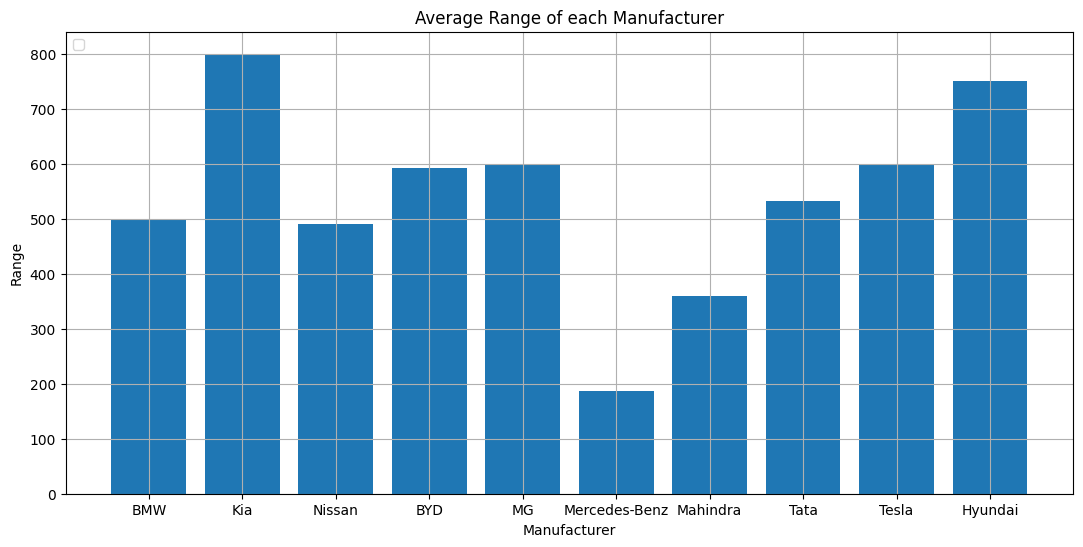

In [77]:
#1. Bar chart:Plot Average range of each manufacturer.
# df['avg_range']=avg_range
plt.figure(figsize=(13,6))
plt.bar(df['Manufacturer'],df['Range'])
plt.xlabel('Manufacturer')
plt.ylabel('Range')
plt.title('Average Range of each Manufacturer')
plt.legend()
plt.grid()
plt.show()

/tmp/ipykernel_6094/1573858581.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


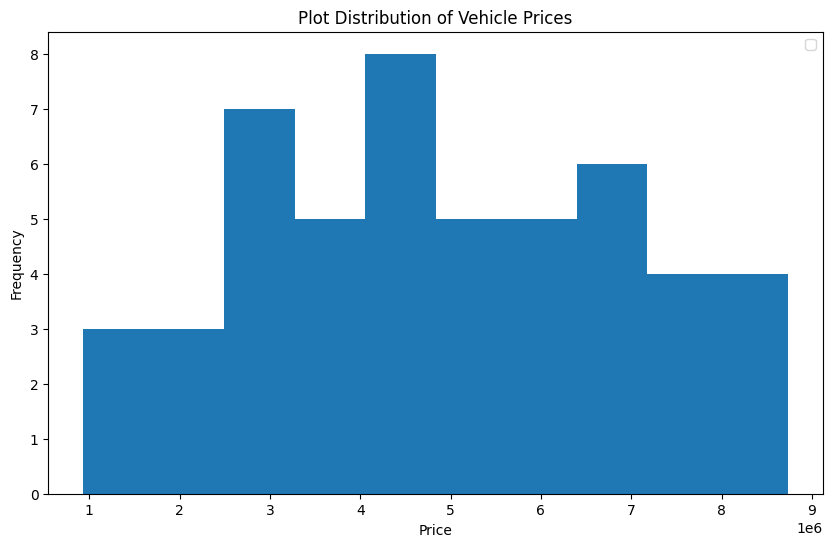

,Vehicle_ID,Manufacturer,Model,Vehicle_Type,Battery_Capacity,Range,Efficiency,Charging_Time,Top_Speed,Motor_Power,Price,Launch_Year,Safety_Rating,Category,avg_range
0,EV1001,BMW,Volt X 1,SUV,60,294,4.9,7.3,214,190,5821705,2019,4.8,Average,NaN
1,EV1002,BMW,Eon EV 7,Hatchback,50,270,5.4,8.4,159,78,3863504,2026,4.4,Average,NaN
2,EV1003,Kia,EcoRide 7,Hatchback,50,420,8.4,2.9,207,262,5505360,2023,3.0,Excellent,NaN
3,EV1004,Kia,Falcon 1,SUV,30,252,8.4,1.4,214,191,936156,2023,4.0,Excellent,NaN
4,EV1005,Nissan,Urban E 3,Hatchback,50,335,6.7,1.8,204,111,7164845,2023,3.8,Good,NaN
5,EV1006,BYD,Neo 6,Hatchback,40,184,4.6,9.5,213,124,8415655,2026,3.9,Average,NaN
6,EV1007,MG,Eon EV 6,Hatchback,60,491,8.2,2.9,215,336,4446968,2022,3.1,Excellent,NaN
7,EV1008,MG,Urban E 5,Hatchback,30,189,6.3,5.9,166,196,1849446,2022,3.8,Good,NaN
8,EV1009,Mercedes-Benz,Eon EV 2,Sedan,30,174,5.8,3.8,145,144,3231662,2019,4.6,Average,NaN
9,EV1010,MG,Drive Pro 1,SUV,50,295,5.9,10.0,148,331,5706619,2022,4.1,Average,NaN


In [88]:
#2. Histogram : Plot distribution of vehicle prices
plt.figure(figsize=(10,6))
plt.hist(df['Price'])
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.title("Plot Distribution of Vehicle Prices")
plt.show()
df

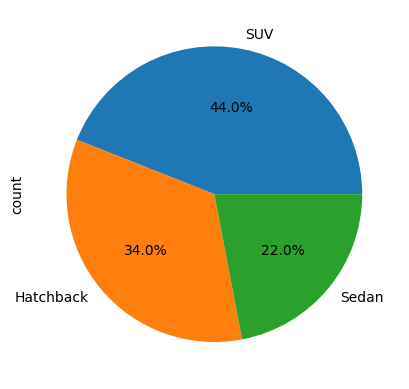

In [94]:
#3. Pie Chart: Vehicle Type Distribution
df['Vehicle_Type'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.show()